# Análisis de Clustering de Clientes de Mall

Este notebook realiza un análisis de clustering (K-Means) sobre datos de clientes de un centro comercial para identificar segmentos de clientes basados en sus ingresos anuales y puntajes de gasto.

## Objetivo
Segmentar a los clientes en grupos distintos para entender mejor sus patrones de comportamiento y diseñar estrategias de marketing personalizadas.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Importación de Librerías

Importamos las librerías necesarias para el análisis:

### pandas (pd)
- **Propósito**: Manipulación y análisis de datos estructurados
- **Principales funciones a usar**:
  - `pd.read_csv()`: leer archivos CSV
  - `DataFrame.head()`: ver primeras filas
  - `DataFrame.rename()`: renombrar columnas

### numpy (np)
- **Propósito**: Operaciones numéricas y álgebra lineal
- **Uso**: Manejo eficiente de arrays y operaciones matemáticas

### seaborn (sns)
- **Propósito**: Visualización estadística de alto nivel
- **Funciones clave**: `pairplot()`, `scatterplot()`, `lineplot()`
- **Ventaja**: Gráficos estéticamente atractivos con menos código

### matplotlib.pyplot (plt)
- **Propósito**: Creación de gráficos y visualizaciones personalizadas
- **Funciones clave**: `xlabel()`, `ylabel()`, `scatter()`, `legend()`

In [2]:
data = pd.read_csv("mall_customers.csv")
display(data.head(5))

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 2. Carga de Datos

### Funciones utilizadas:

#### `pd.read_csv("mall_customers.csv")`
- **Propósito**: Lee un archivo CSV y lo convierte en un DataFrame de pandas
- **Parámetros principales**:
  - Ruta del archivo (puede ser relativa o absoluta)
  - `sep`: delimitador (por defecto es coma)
  - `encoding`: codificación del archivo
- **Retorna**: DataFrame con los datos del CSV

#### `display(data.head(5))`
- **display()**: Función de Jupyter que muestra el DataFrame de forma formateada
- **data.head(5)**: Muestra las primeras 5 filas del DataFrame
  - Útil para inspección rápida de datos
  - Por defecto muestra 5 filas, pero se puede especificar otro número

### Estructura del dataset:
- ID del cliente
- Género
- Edad
- Ingreso anual (en miles de dólares)
- Puntaje de gasto (escala 1-100)

In [4]:
data.rename({"Annual Income (k$)": "Income", "Spending Score (1-100)": "Spending Score"}, axis=1, inplace=True)
display(data.head(5))

,CustomerID,Gender,Age,Income,Spending Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 3. Limpieza y Preparación de Datos

### Función utilizada:

#### `data.rename()`
```python
data.rename({"columna_vieja": "columna_nueva"}, axis=1, inplace=True)
```

**Parámetros**:
- **Primer argumento (diccionario)**: Mapeo de nombres antiguos a nuevos
  - Clave: nombre actual de la columna
  - Valor: nuevo nombre deseado
- **axis=1**: Indica que estamos renombrando columnas (axis=0 sería para filas)
- **inplace=True**: Modifica el DataFrame original sin crear una copia
  - Si fuera False (default), retornaría un nuevo DataFrame

**En nuestro caso**:
- `Annual Income (k$)` → `Income` (más conciso)
- `Spending Score (1-100)` → `Spending Score` (elimina el rango del nombre)

**Ventaja**: Nombres más cortos y fáciles de usar en el código

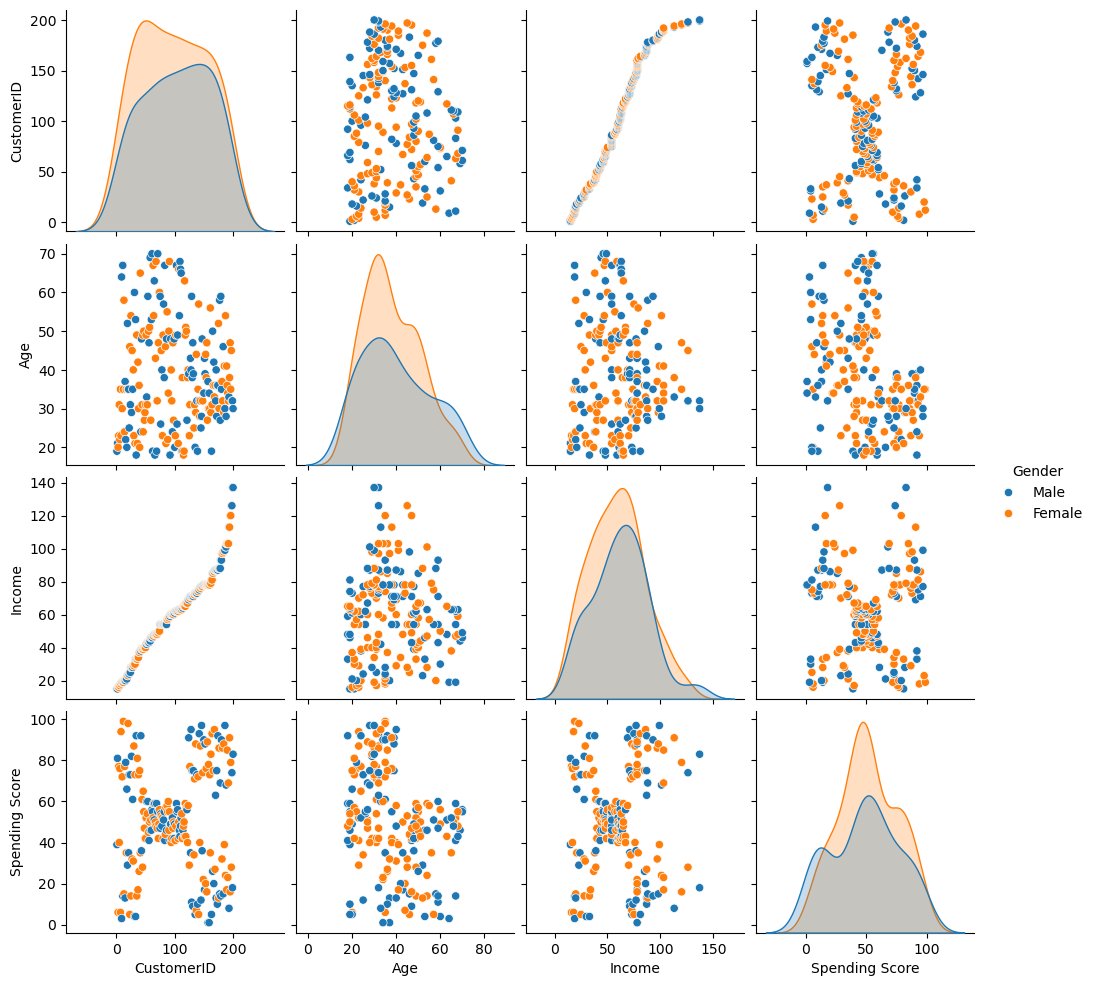

In [5]:
sns.pairplot(data, hue='Gender')

## 4. Análisis Exploratorio de Datos (EDA)

### Función utilizada:

#### `sns.pairplot(data, hue='Gender')`

**Propósito**: Crea una matriz de gráficos que muestra:
- Distribuciones univariadas (diagonal): histogramas de cada variable
- Relaciones bivariadas (fuera de diagonal): scatter plots entre pares de variables

**Parámetros**:
- **data**: DataFrame con los datos a visualizar
- **hue='Gender'**: Variable categórica para colorear los puntos
  - Cada género se muestra en un color diferente
  - Permite identificar patrones específicos por grupo

**Lo que nos ayuda a identificar**:
- **Correlaciones**: ¿Las variables están relacionadas linealmente?
- **Distribuciones**: ¿Los datos son normales, sesgados, bimodales?
- **Outliers**: Puntos que se alejan significativamente del patrón general
- **Diferencias por género**: ¿Hombres y mujeres tienen patrones distintos?

**Interpretación**:
- Puntos agrupados → correlación positiva
- Puntos dispersos → poca o ninguna correlación
- Línea descendente → correlación negativa

In [6]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X = data[['Income', 'Spending Score']]
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)  


## 5. Preparación de Datos para Clustering

### Selección de Features
```python
X = data[['Income', 'Spending Score']]
```
- **Sintaxis con doble corchete**: Crea un DataFrame (no una Serie)
- Seleccionamos solo las columnas numéricas relevantes para clustering
- Excluimos CustomerID (identificador) y Gender (categórica sin encoding)

### Funciones de Escalado:

#### `StandardScaler()`
**Propósito**: Estandariza las características para que tengan:
- Media (μ) = 0
- Desviación estándar (σ) = 1

**Fórmula aplicada**: 
$$z = \frac{x - \mu}{\sigma}$$

Donde:
- $x$ = valor original
- $\mu$ = media de la característica
- $\sigma$ = desviación estándar

#### `scaler.fit_transform(X)`
**Función combinada que hace dos cosas**:

1. **fit()**: "Aprende" los parámetros del conjunto de datos
   - Calcula la media y desviación estándar de cada columna
   - Guarda estos valores en el objeto scaler

2. **transform()**: Aplica la transformación usando los parámetros aprendidos
   - Convierte los datos originales a escala estandarizada
   - Retorna un array numpy con los datos transformados

**¿Por qué es crucial para K-Means?**
- K-Means usa distancias euclidanas para agrupar
- Si Income está en miles (15-140) y Score en 1-100, Income dominaría
- StandardScaler iguala la influencia de ambas variables
- Sin escalar: variables con mayor rango influyen más en los clusters

**Ejemplo**:
- Income original: [15, 20, 137] → Escalado: [-1.2, -0.9, 2.1]
- Score original: [40, 80, 60] → Escalado: [-0.7, 1.4, -0.7]

In [7]:
kmeans = KMeans(n_clusters=5, n_init = 10, random_state=0)
kmeans.fit(X_scaled)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_

## 6. Aplicación del Algoritmo K-Means

### Funciones utilizadas:

#### `KMeans(n_clusters=5, n_init=10, random_state=0)`
**Inicializa el modelo K-Means con parámetros específicos**

**Parámetros**:

- **n_clusters=5**: Número de clusters (grupos) a formar
  - Define cuántos centroides se inicializarán
  - Debe ser menor que el número de muestras
  
- **n_init=10**: Número de ejecuciones con diferentes inicializaciones
  - K-Means puede caer en óptimos locales según la inicialización
  - Ejecuta el algoritmo 10 veces con semillas aleatorias diferentes
  - Selecciona el mejor resultado (menor inercia)
  - Más n_init = más tiempo pero mejor resultado
  
- **random_state=0**: Semilla aleatoria para reproducibilidad
  - Fija la generación de números aleatorios
  - Permite obtener los mismos resultados en cada ejecución
  - Útil para debugging y presentaciones

**Otros parámetros comunes** (no usados aquí):
- `max_iter=300`: iteraciones máximas por ejecución
- `algorithm='lloyd'`: variante del algoritmo a usar

#### `kmeans.fit(X_scaled)`
**Entrena el modelo con los datos escalados**

**Proceso interno**:
1. Inicializa k centroides aleatoriamente
2. Asigna cada punto al centroide más cercano
3. Recalcula los centroides como el promedio de los puntos asignados
4. Repite pasos 2-3 hasta convergencia o max_iter

**Convergencia**: Se alcanza cuando:
- Los centroides ya no se mueven significativamente
- O se alcanza el número máximo de iteraciones

#### `kmeans.labels_`
**Atributo que contiene las etiquetas de cluster**
- Array de tamaño n_samples
- Cada elemento es un número de 0 a (n_clusters-1)
- Indica a qué cluster pertenece cada observación
- Ejemplo: [0, 2, 1, 0, 4] → punto 1 en cluster 0, punto 2 en cluster 2, etc.

#### `kmeans.cluster_centers_`
**Atributo con las coordenadas de los centroides**
- Array de forma (n_clusters, n_features)
- Cada fila representa un centroide
- Cada columna representa una dimensión (Income, Spending Score)
- Son los "centros" de cada cluster en el espacio de características

**Ejemplo de centroides**:
```
array([[-1.2,  0.8],    # Centroide cluster 0
       [ 0.5, -1.1],    # Centroide cluster 1
       [ 1.8,  1.5]])   # Centroide cluster 2
```

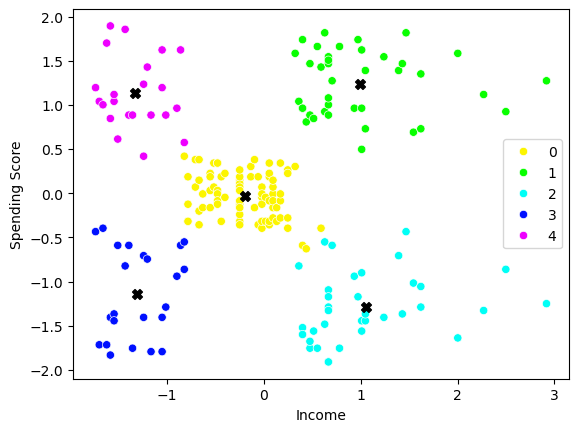

In [8]:
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=labels, palette=sns.color_palette("hsv", 5), legend='full')
plt.xlabel('Income'); plt.ylabel('Spending Score');
plt.scatter(centroids[:, 0], centroids[:, 1], s=50, c='black', marker='X', label='Centroids')

## 7. Visualización de Clusters

### Funciones utilizadas:

#### `sns.scatterplot()`
```python
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=labels, 
                palette=sns.color_palette("hsv", 5), legend='full')
```

**Propósito**: Crea un gráfico de dispersión (scatter plot) con colores por cluster

**Parámetros explicados**:
- **x=X_scaled[:, 0]**: Coordenadas en el eje X (primera columna = Income)
  - `[:, 0]` = todas las filas, columna 0
- **y=X_scaled[:, 1]**: Coordenadas en el eje Y (segunda columna = Spending Score)
  - `[:, 1]` = todas las filas, columna 1
- **hue=labels**: Variable para colorear los puntos
  - Cada valor único de labels recibe un color diferente
  - Permite distinguir visualmente los clusters
- **palette=sns.color_palette("hsv", 5)**: Paleta de colores
  - `"hsv"`: espacio de colores HSV (matiz, saturación, valor)
  - `5`: genera 5 colores distintos y equidistantes
- **legend='full'**: Muestra la leyenda completa con todos los clusters

#### `plt.xlabel('Income')` y `plt.ylabel('Spending Score')`
**Propósito**: Añade etiquetas a los ejes
- Mejora la interpretabilidad del gráfico
- Indica qué representa cada eje

#### `plt.scatter(centroids[:, 0], centroids[:, 1], ...)`
```python
plt.scatter(centroids[:, 0], centroids[:, 1], s=50, c='black', 
            marker='X', label='Centroids')
```

**Propósito**: Superpone los centroides sobre el gráfico de clusters

**Parámetros**:
- **centroids[:, 0]**: Coordenada X de cada centroide
- **centroids[:, 1]**: Coordenada Y de cada centroide
- **s=50**: Tamaño de los marcadores (50 puntos)
- **c='black'**: Color de los marcadores (negro para destacar)
- **marker='X'**: Forma del marcador (X grande)
  - Otras opciones: 'o' (círculo), '*' (estrella), '^' (triángulo)
- **label='Centroids'**: Etiqueta para la leyenda

**Resultado**: Un gráfico que muestra:
- Puntos coloreados por cluster
- Centroides marcados con X negras
- Leyenda identificando cada elemento

Text(0, 0.5, 'Sumas dist cuadraticas')

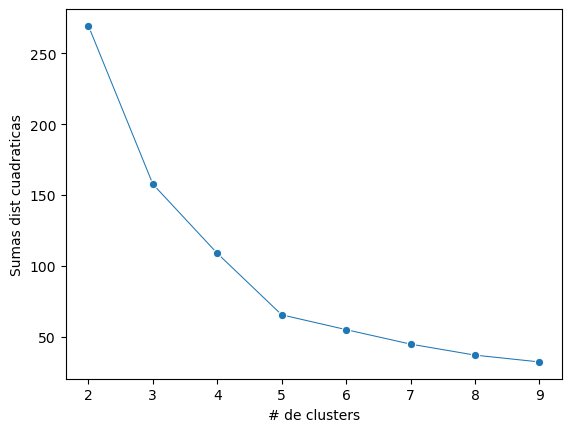

In [9]:
sq_distances=[]
k_values=range(2,10)

for k in k_values:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=0)
    kmeans.fit(X_scaled)
    sq_distances.append(kmeans.inertia_)

sns.lineplot(x=k_values, y=sq_distances, marker='o', size=30, legend=False)
plt.xlabel('# de clusters')
plt.ylabel('Sumas dist cuadraticas')

## 8. Método del Codo (Elbow Method)

Evaluamos diferentes números de clusters (k=2 a k=9) para encontrar el número óptimo.

### Funciones y conceptos utilizados:

#### `range(2, 10)`
**Propósito**: Genera una secuencia de números de 2 a 9 (10 no incluido)
- Probamos desde 2 clusters (mínimo útil) hasta 9
- 1 cluster no tiene sentido para segmentación

#### Bucle `for k in k_values:`
**Propósito**: Itera sobre cada valor de k para entrenar múltiples modelos

**Proceso en cada iteración**:
1. `KMeans(n_clusters=k, ...)`: Crea modelo con k clusters
2. `kmeans.fit(X_scaled)`: Entrena el modelo
3. `kmeans.inertia_`: Obtiene la inercia del modelo

#### `kmeans.inertia_`
**Propósito**: Métrica de compactación de clusters

**Definición matemática**:
$$\text{Inercia} = \sum_{i=1}^{n} \min_{\mu_j \in C} (||x_i - \mu_j||^2)$$

Donde:
- $x_i$ = punto de datos i
- $\mu_j$ = centroide del cluster j
- $C$ = conjunto de todos los centroides

**En palabras simples**:
- Suma de las distancias cuadráticas de cada punto a su centroide
- Menor inercia = puntos más cercanos a sus centroides
- Clusters más compactos y homogéneos

#### `sq_distances.append(kmeans.inertia_)`
**Propósito**: Almacena la inercia de cada modelo en una lista
- Permite comparar la inercia para diferentes valores de k
- Lista resultante: [inercia_k2, inercia_k3, ..., inercia_k9]

#### `sns.lineplot(x=k_values, y=sq_distances, marker='o', size=30, legend=False)`
**Propósito**: Visualiza la curva del codo

**Parámetros**:
- **x=k_values**: Eje X con número de clusters (2-9)
- **y=sq_distances**: Eje Y con valores de inercia
- **marker='o'**: Marca cada punto con un círculo
- **size=30**: Tamaño de la línea (grosor)
- **legend=False**: Oculta la leyenda (no necesaria aquí)

### ¿Qué es la inercia?
- Suma de las distancias cuadráticas de cada punto a su centroide más cercano
- **Menor inercia** = clusters más compactos
- **Más clusters** = siempre menor inercia (en el límite: n clusters = n puntos, inercia = 0)

### Interpretación del gráfico:
1. **Buscar el "codo"**: Punto donde la curva cambia de pendiente pronunciada a suave
2. **Antes del codo**: Cada cluster adicional mejora mucho la compactación
3. **Después del codo**: Mejoras marginales, posible overfitting
4. **El codo indica**: Balance óptimo entre simplicidad y calidad

**Ejemplo de interpretación**:
- Si el codo está en k=5: Usar más de 5 clusters no mejora significativamente
- La mejora de k=5 a k=6 es mucho menor que de k=4 a k=5

Text(0, 0.5, 'Silhouette Score')

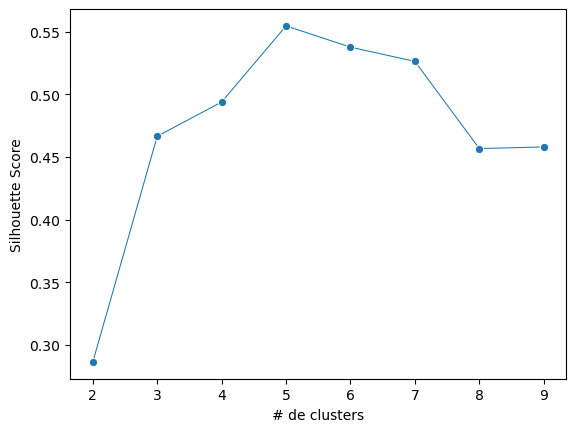

In [10]:
from sklearn.metrics import silhouette_score, silhouette_samples

sil=[]
k_values=range(2,10)

for k in k_values:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=0)
    kmeans.fit(X_scaled)
    labels = kmeans.labels_
    score = silhouette_score(X_scaled, kmeans.labels_)
    sil.append(score)
    
sns.lineplot(x=k_values, y=sil, marker='o', size=30, legend=False)
plt.xlabel('# de clusters')
plt.ylabel('Silhouette Score')



## 9. Coeficiente de Silueta (Silhouette Score)

Métrica complementaria al método del codo para determinar el número óptimo de clusters.

### Funciones utilizadas:

#### `silhouette_score(X_scaled, kmeans.labels_)`
**Propósito**: Calcula el coeficiente de silueta promedio para todos los puntos

**Parámetros**:
- **X_scaled**: Datos escalados (matriz de características)
- **kmeans.labels_**: Etiquetas de cluster asignadas por K-Means

**Fórmula del coeficiente de silueta para un punto**:
$$s = \frac{b - a}{\max(a, b)}$$

Donde:
- $a$ = distancia promedio a puntos del mismo cluster (cohesión intra-cluster)
- $b$ = distancia promedio al cluster más cercano (separación inter-cluster)

**Cálculo detallado**:
1. Para cada punto $i$:
   - $a(i)$ = distancia promedio a otros puntos de su cluster
   - $b(i)$ = distancia promedio al cluster vecino más cercano
   - $s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$
2. Silhouette Score = promedio de $s(i)$ para todos los puntos

#### `silhouette_samples` (importado pero no usado en el código)
**Propósito**: Calcula el coeficiente de silueta individual para cada muestra
- Retorna un array con el score de cada punto
- Útil para identificar puntos mal clasificados
- Permite crear gráficos de silueta detallados

### ¿Qué mide el Silhouette Score?

**Rango de valores: -1 a 1**

- **Cercano a +1**: 
  - El punto está bien asignado a su cluster
  - Distancia a su cluster << distancia al cluster más cercano
  - Clusters bien separados y compactos

- **Cercano a 0**: 
  - El punto está en el límite entre dos clusters
  - Distancia a su cluster ≈ distancia al cluster vecino
  - Ambigüedad en la asignación

- **Negativo** (-1): 
  - El punto probablemente está mal asignado
  - Está más cerca de otro cluster que del suyo
  - Debería pertenecer al cluster vecino

### Interpretación práctica:

**Score global (promedio)**:
- **0.71 - 1.00**: Estructura muy fuerte, clusters muy bien definidos
- **0.51 - 0.70**: Estructura razonable, clusters bien separados
- **0.26 - 0.50**: Estructura débil, algunos solapamientos
- **< 0.25**: Sin estructura sustancial, clusters artificiales

### Ventajas sobre el método del codo:
1. **Valor absoluto interpretable**: No solo tendencias
2. **Considera separación**: No solo compactación
3. **Penaliza overlap**: Detecta clusters mal definidos
4. **Menos subjetivo**: No requiere identificar visualmente un "codo"

### Uso conjunto:
- **Método del codo**: Identifica rango de valores óptimos
- **Silhouette Score**: Confirma y refina la elección
- **Criterio**: Maximizar silhouette score dentro del rango del codo

### En el bucle:
```python
for k in k_values:
    kmeans = KMeans(n_clusters=k, ...)  # Crea modelo
    kmeans.fit(X_scaled)                # Entrena modelo
    labels = kmeans.labels_             # Obtiene asignaciones
    score = silhouette_score(X_scaled, labels)  # Calcula score
    sil.append(score)                   # Guarda para graficar
```

**Resultado esperado**:
- Curva que muestra cómo varía la calidad con k
- Buscamos el máximo (pico) de la curva
- Ese k proporciona la mejor separación y cohesión

## 10. Conclusiones

Basándose en los resultados del Método del Codo y el Coeficiente de Silueta, se puede determinar el número óptimo de clusters para segmentar a los clientes del mall.

### Interpretación de Segmentos (ejemplo con 5 clusters):
Los clusters típicamente representan grupos como:
1. **Bajos ingresos, bajo gasto**: clientes cautelosos con recursos limitados
2. **Bajos ingresos, alto gasto**: jóvenes o clientes impulsivos
3. **Ingresos medios, gasto medio**: clientes promedio
4. **Altos ingresos, bajo gasto**: clientes conservadores/ahorradores
5. **Altos ingresos, alto gasto**: clientes premium/objetivo principal

### Aplicaciones:
- Diseñar campañas de marketing personalizadas para cada segmento
- Optimizar estrategias de precios
- Mejorar la experiencia del cliente según su perfil